# 22 09 2026

In [1]:

import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("C:/Users/abhijit/Downloads/archive/Sample - Superstore.csv",encoding="windows-1251")

In [3]:
print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [5]:
print(df.describe())

            Row ID   Postal Code         Sales     Quantity     Discount  \
count  9994.000000   9994.000000   9994.000000  9994.000000  9994.000000   
mean   4997.500000  55190.379428    229.858001     3.789574     0.156203   
std    2885.163629  32063.693350    623.245101     2.225110     0.206452   
min       1.000000   1040.000000      0.444000     1.000000     0.000000   
25%    2499.250000  23223.000000     17.280000     2.000000     0.000000   
50%    4997.500000  56430.500000     54.490000     3.000000     0.200000   
75%    7495.750000  90008.000000    209.940000     5.000000     0.200000   
max    9994.000000  99301.000000  22638.480000    14.000000     0.800000   

            Profit  
count  9994.000000  
mean     28.656896  
std     234.260108  
min   -6599.978000  
25%       1.728750  
50%       8.666500  
75%      29.364000  
max    8399.976000  


In [6]:
print(df.dtypes)

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [7]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])
print(df.dtypes)

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object


In [8]:
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [9]:
print(df.duplicated().sum())

0


In [11]:
print(df[["Sales","Quantity","Discount","Profit"]].describe())

              Sales     Quantity     Discount       Profit
count   9994.000000  9994.000000  9994.000000  9994.000000
mean     229.858001     3.789574     0.156203    28.656896
std      623.245101     2.225110     0.206452   234.260108
min        0.444000     1.000000     0.000000 -6599.978000
25%       17.280000     2.000000     0.000000     1.728750
50%       54.490000     3.000000     0.200000     8.666500
75%      209.940000     5.000000     0.200000    29.364000
max    22638.480000    14.000000     0.800000  8399.976000


In [12]:
category_sales = df.groupby("Category")["Sales"].sum()
print(category_sales)


Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64


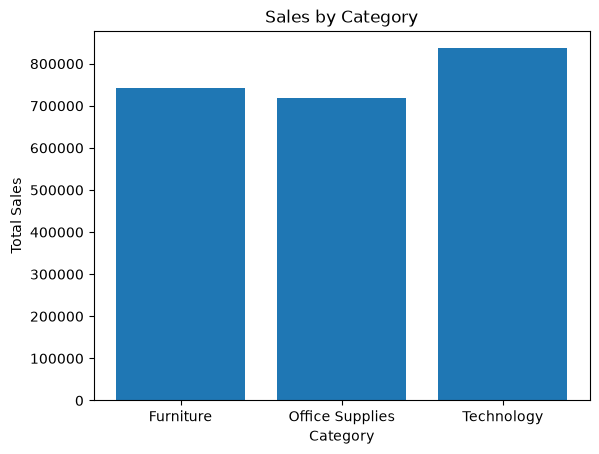

In [13]:
plt.bar(category_sales.index,category_sales.values)
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

In [17]:
subcategory_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)
print(subcategory_sales)

Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91705.1640
Paper           78479.2060
Supplies        46673.5380
Art             27118.7920
Envelopes       16476.4020
Labels          12486.3120
Fasteners        3024.2800
Name: Sales, dtype: float64


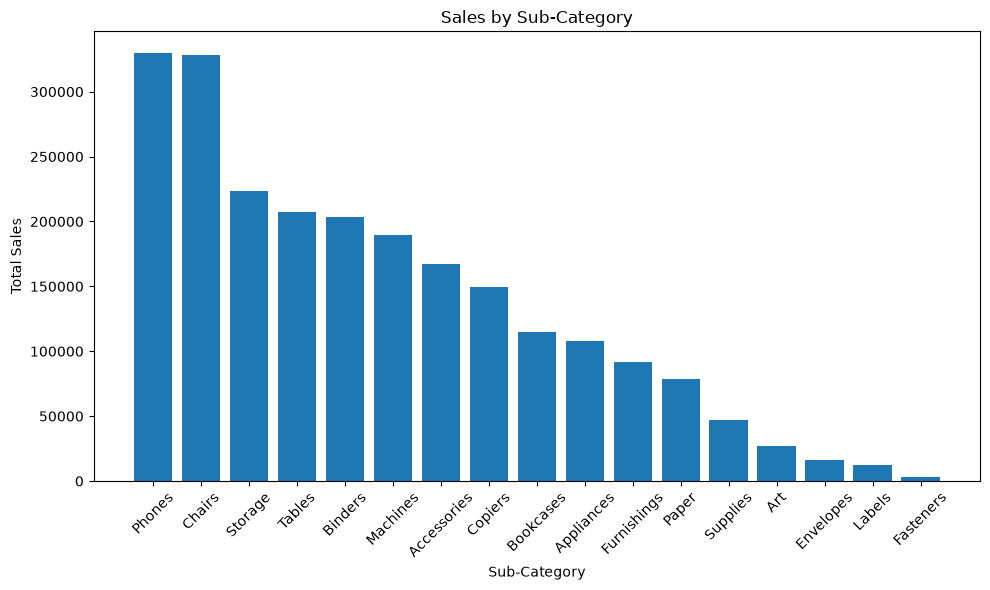

In [20]:
plt.figure(figsize=(10,6))
plt.bar(subcategory_sales.index, subcategory_sales.values)

plt.title("Sales by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
df["Month"] = df["Order Date"].dt.to_period("M")
monthly_sales = (df.groupby("Month")["Sales"].sum())
print(monthly_sales)

Month
2014-01     14236.8950
2014-02      4519.8920
2014-03     55691.0090
2014-04     28295.3450
2014-05     23648.2870
2014-06     34595.1276
2014-07     33946.3930
2014-08     27909.4685
2014-09     81777.3508
2014-10     31453.3930
2014-11     78628.7167
2014-12     69545.6205
2015-01     18174.0756
2015-02     11951.4110
2015-03     38726.2520
2015-04     34195.2085
2015-05     30131.6865
2015-06     24797.2920
2015-07     28765.3250
2015-08     36898.3322
2015-09     64595.9180
2015-10     31404.9235
2015-11     75972.5635
2015-12     74919.5212
2016-01     18542.4910
2016-02     22978.8150
2016-03     51715.8750
2016-04     38750.0390
2016-05     56987.7280
2016-06     40344.5340
2016-07     39261.9630
2016-08     31115.3743
2016-09     73410.0249
2016-10     59687.7450
2016-11     79411.9658
2016-12     96999.0430
2017-01     43971.3740
2017-02     20301.1334
2017-03     58872.3528
2017-04     36521.5361
2017-05     44261.1102
2017-06     52981.7257
2017-07     45264.4160
2017-

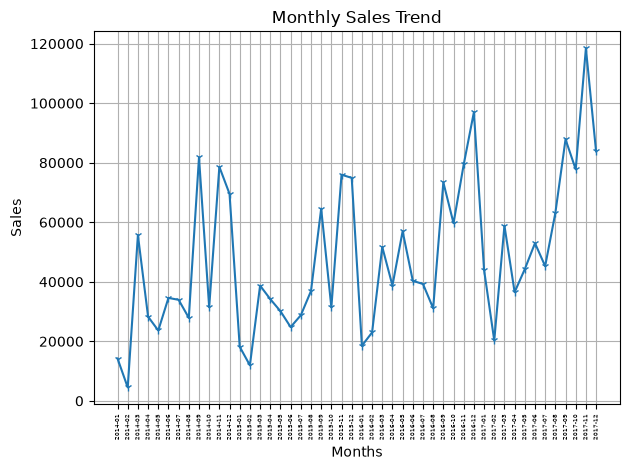

In [33]:
plt.Figure(figsize=(12,6))
plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker = "1"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Months")
plt.ylabel("Sales")

plt.xticks(rotation=90, fontsize=4)
plt.grid(True)
plt.tight_layout()
plt.show()

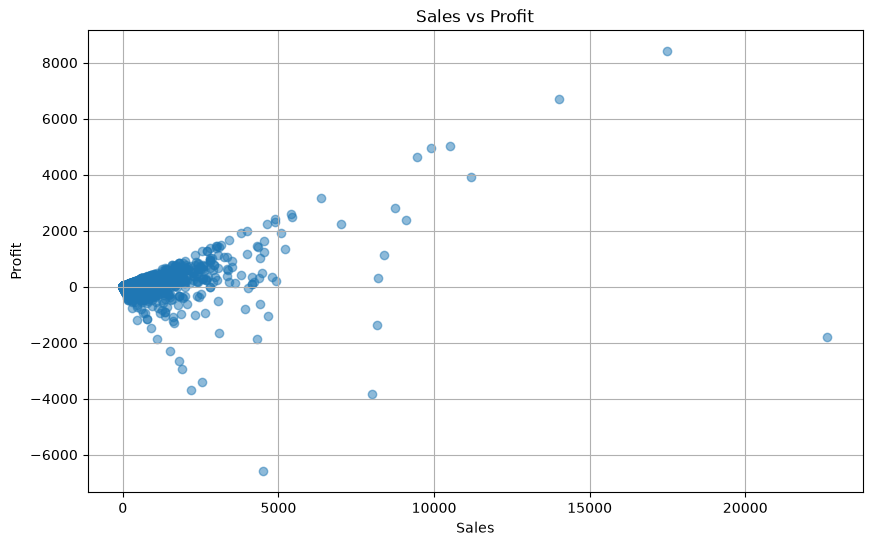

In [ ]:
# sales vs profit relationship
plt.figure(figsize=(10,6))
plt.scatter(
    df["Sales"],
    df["Profit"],
    alpha = 0.5   # alpha is used to make the points transparent
)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.grid()
plt.show()

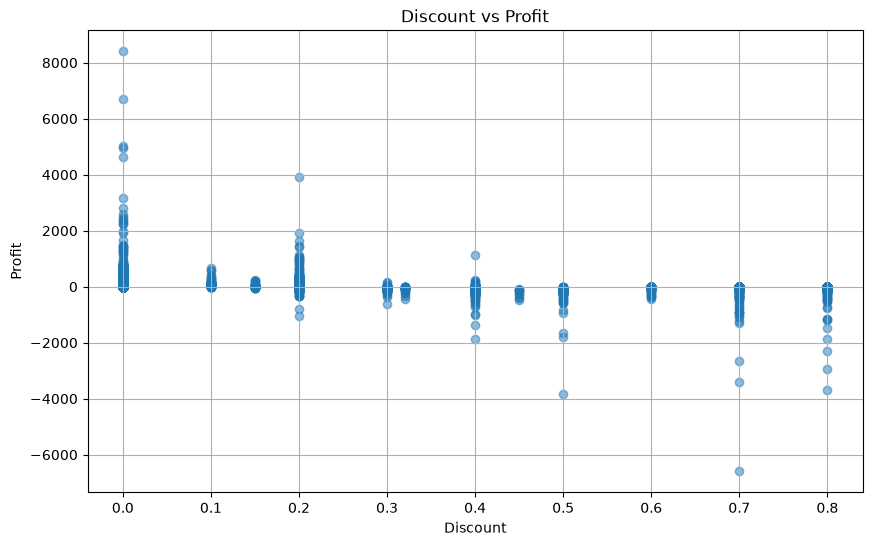

In [37]:
# discount vs profit relationship
plt.figure(figsize=(10,6))
plt.scatter(
    df["Discount"],
    df["Profit"],
    alpha = 0.5   # alpha is used to make the points transparent
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.grid()
plt.show()

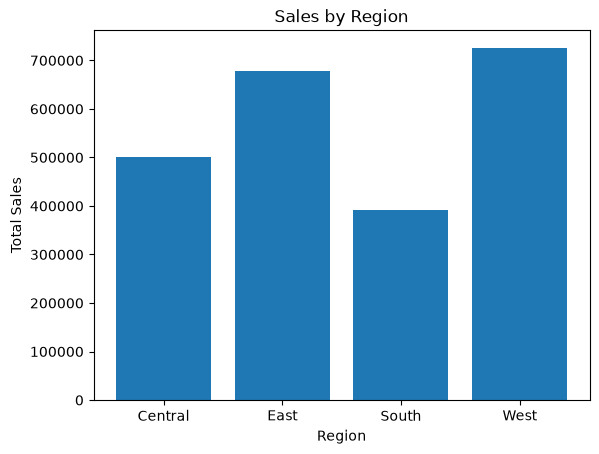

In [38]:
region_sales =(
    df.groupby("Region")["Sales"].sum()
    
)
plt.bar(region_sales.index,region_sales.values)
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

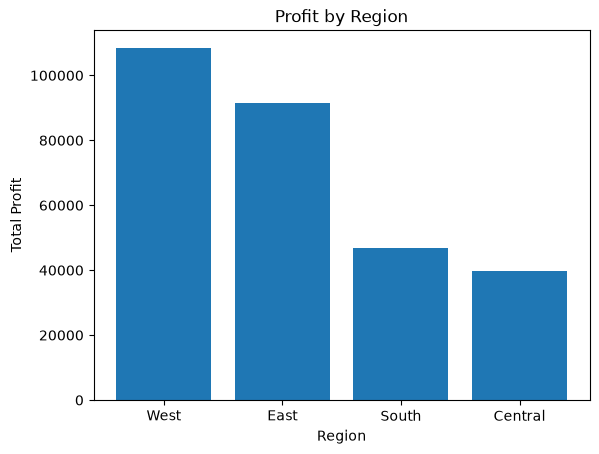

In [40]:
# profit by region bar chart
region_profit =(
    df.groupby("Region")["Profit"].sum().sort_values(ascending=False)
    
)
plt.bar(region_profit.index,region_profit.values)
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.show()

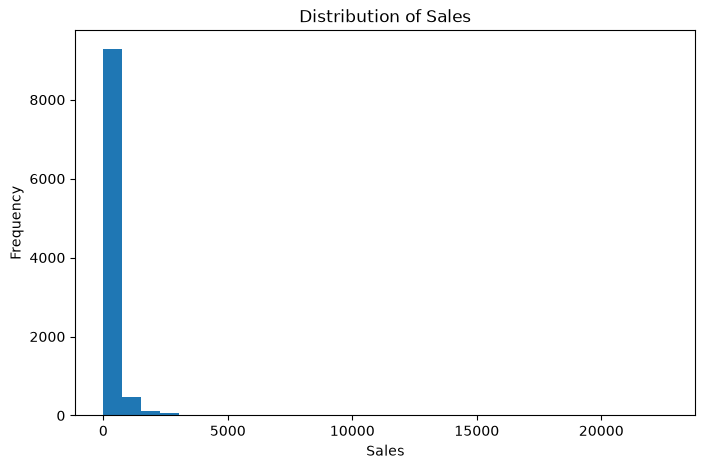

In [45]:
plt.figure(figsize=(8,5))

plt.hist(df["Sales"],bins=30) #bins is used for the number of bars
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

In [48]:
# top 10 product by sales
top_products = (
    df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)
)
print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


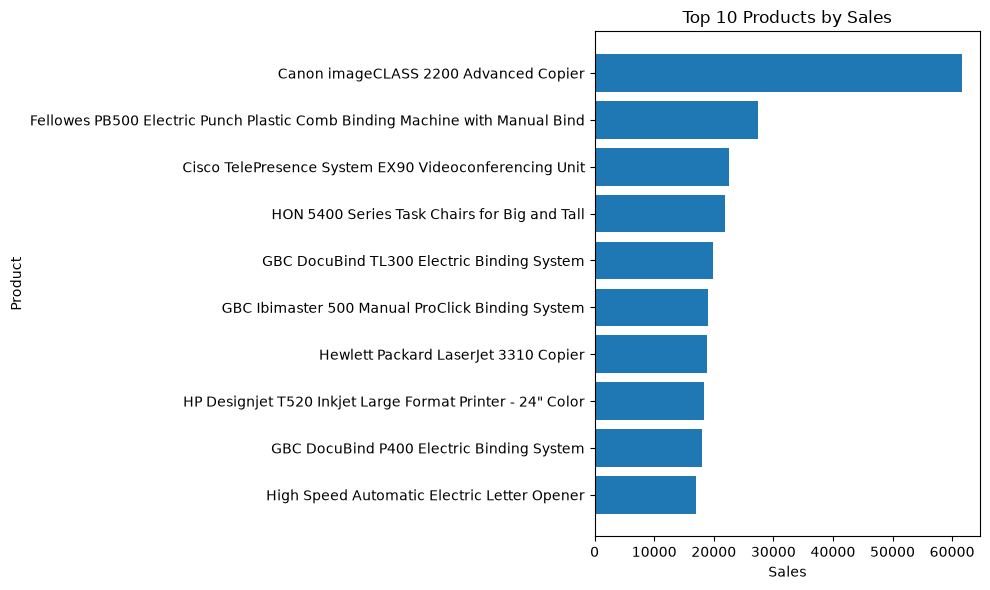

In [49]:
plt.figure(figsize = (10,6))

plt.barh(top_products.index,top_products.values)

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

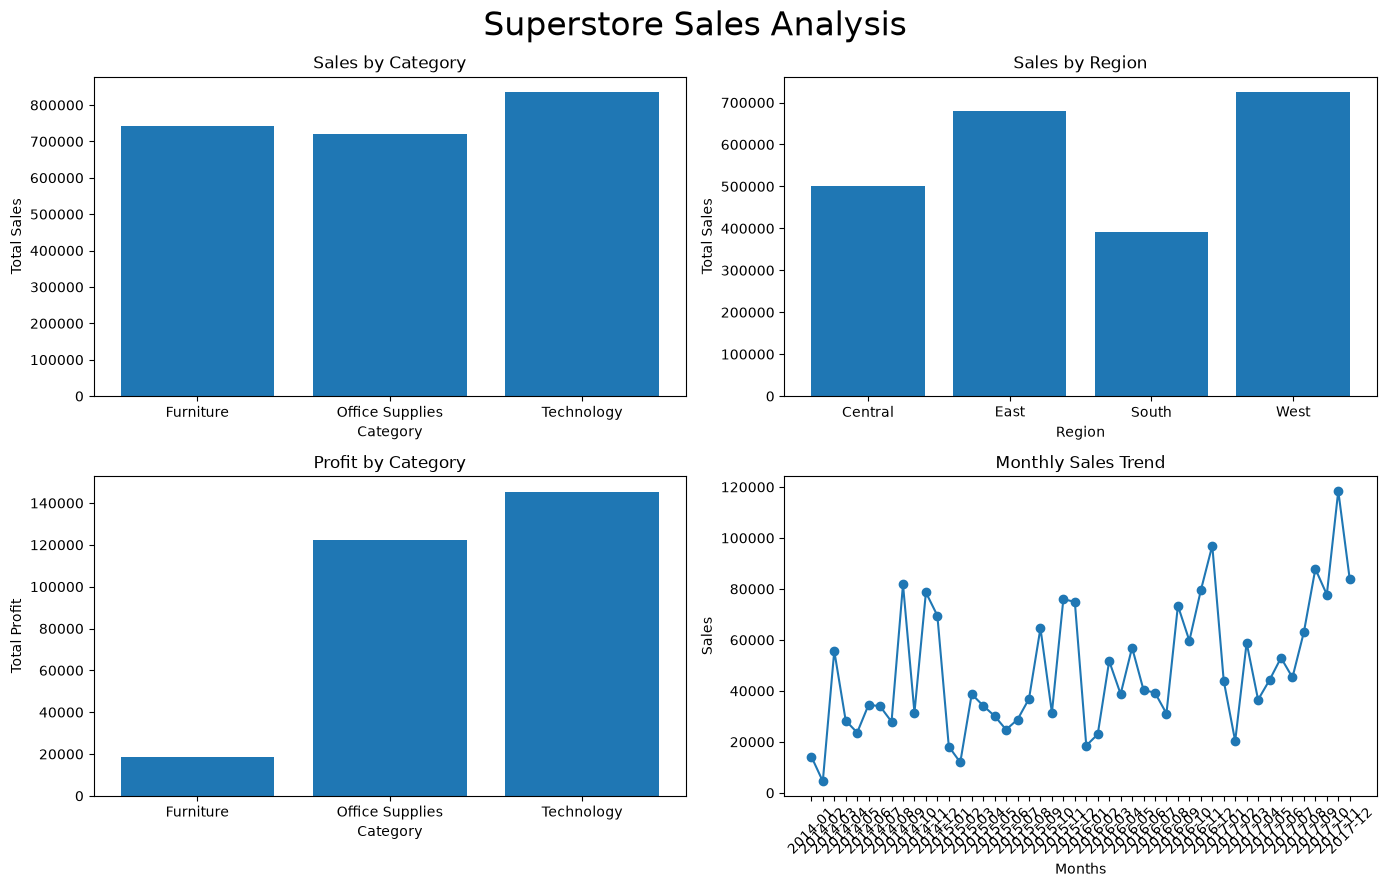

In [53]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
category_sales = (df.groupby("Category")["Sales"].sum())
region_sales = (df.groupby("Region")["Sales"].sum())
category_profit = (df.groupby("Category")["Profit"].sum())
monthly_sales = (df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum())

fig,axes = plt.subplots(2,2,figsize=(14,9))

# category sales
axes[0,0].bar(category_sales.index,category_sales.values)
axes[0,0].set_title("Sales by Category")
axes[0,0].set_xlabel("Category")
axes[0,0].set_ylabel("Total Sales")

# region sales
axes[0,1].bar(region_sales.index,region_sales.values)
axes[0,1].set_title("Sales by Region")
axes[0,1].set_xlabel("Region")
axes[0,1].set_ylabel("Total Sales")

# category profit
axes[1,0].bar(category_profit.index,category_profit.values)
axes[1,0].set_title("Profit by Category")
axes[1,0].set_xlabel("Category")
axes[1,0].set_ylabel("Total Profit")

axes[1,1].plot(monthly_sales.index.astype(str),monthly_sales.values, marker="o")
axes[1,1].set_title("Monthly Sales Trend")
axes[1,1].set_xlabel("Months")
axes[1,1].set_ylabel("Sales")

axes[1,1].tick_params(axis='x', rotation=45)

fig.suptitle("Superstore Sales Analysis", fontsize=24)

plt.tight_layout()
plt.show()

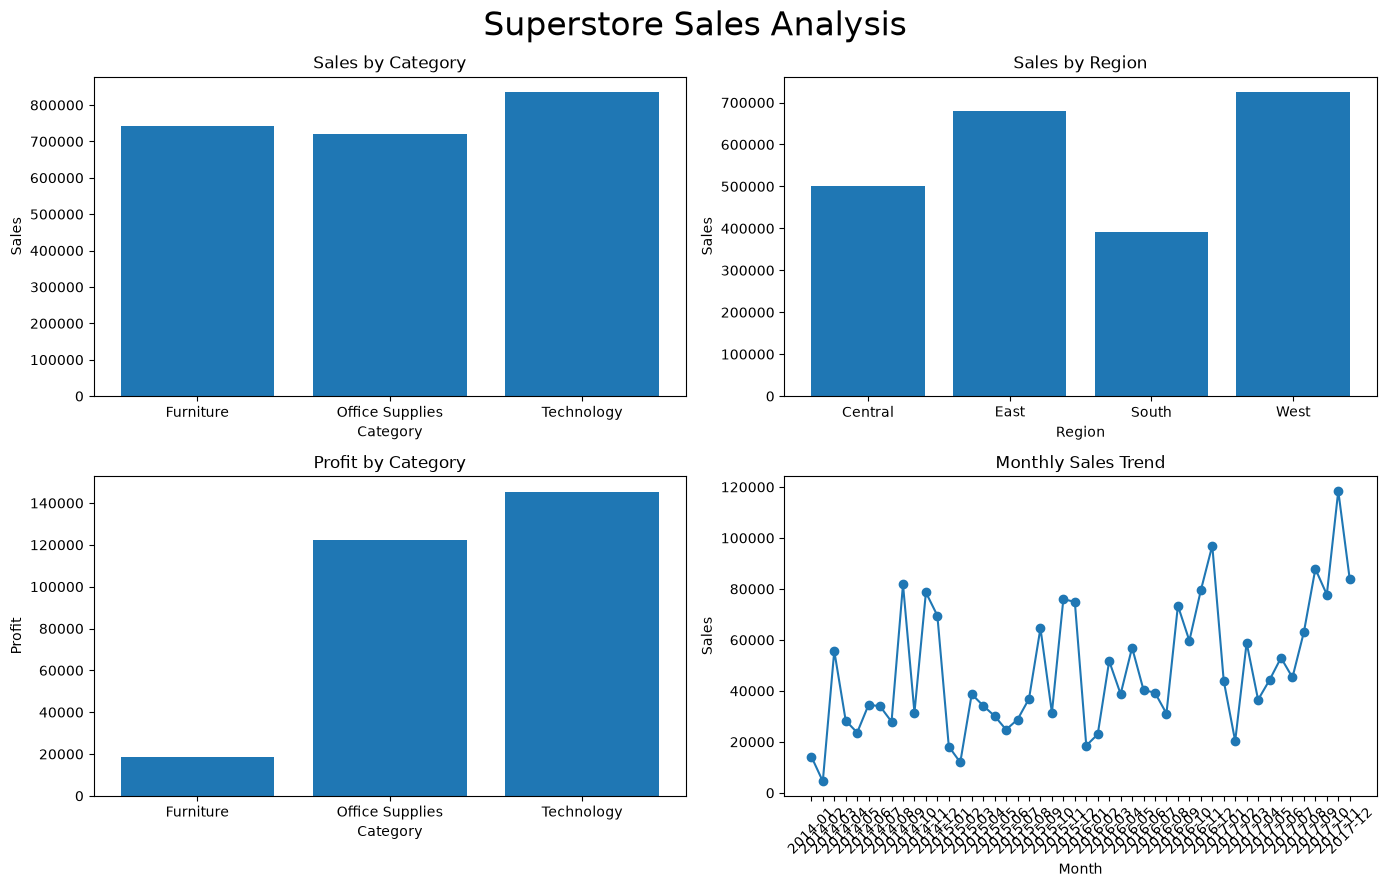

In [54]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
category_Sales = (df.groupby("Category")["Sales"].sum())
region_Sales = (df.groupby("Region")["Sales"].sum())
category_Profit = (df.groupby("Category")["Profit"].sum())
monthly_Sales = (df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum())

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# category Sales
axes[0,0].bar(category_Sales.index,category_Sales.values)

axes[0,0].set_title("Sales by Category")
axes[0,0].set_xlabel("Category")
axes[0,0].set_ylabel("Sales")

# Region Sales
axes[0,1].bar(region_Sales.index,region_Sales.values)

axes[0,1].set_title("Sales by Region")
axes[0,1].set_xlabel("Region")
axes[0,1].set_ylabel("Sales")


# category Profit
axes[1,0].bar(category_Profit.index,category_Profit.values)

axes[1,0].set_title("Profit by Category")
axes[1,0].set_xlabel("Category")
axes[1,0].set_ylabel("Profit")

axes[1,1].plot(monthly_Sales.index.astype(str),monthly_Sales.values, marker="o")
axes[1,1].set_title("Monthly Sales Trend")
axes[1,1].set_xlabel("Month")
axes[1,1].set_ylabel("Sales")

axes[1,1].tick_params(axis="x",rotation = 45)

fig.suptitle("Superstore Sales Analysis", fontsize = 24)

plt.tight_layout()
plt.show()